# 1. Coneccion con Amazon

En Amazon, tienen un sistema anti codigo, osea que si intento bajar informacion me saldra estado de codigo 503 (Servicio no disponible), por eso gracias a una linea de codigo headers se puede llegar al esta 202 ( solcitud aceptada semi completa)

In [1]:
import requests
url = "https://www.amazon.com"
respuesta = requests.get(url)
print("Status code:", respuesta.status_code)

if respuesta.status_code == 200:
    print("Conexión exitosa")
else:
    print("No se pudo acceder correctamente")

c:\Users\fejor\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


Status code: 503
No se pudo acceder correctamente


In [ ]:
import requests

url = "https://www.amazon.com"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0 Safari/537.36"
}

respuesta = requests.get(url, headers=headers)

print("Status code:", respuesta.status_code)
print("Content-Type:", respuesta.headers.get("Content-Type"))

Status code: 202
Content-Type: text/html; charset=UTF-8


producto = "audifinos inalambricos"

https://www.amazon.com/s?k=caja&__mk_es_US=%C3%85M%C3%85%C5%BD%C3%95%C3%91&crid=2EJ28KPN713RD&sprefix=ca%2Caps%2C356&ref=nb_sb_noss_2

https://www.amazon.com/s?k=audifonos+inalambricos&crid=22KU3N8QD3H7J&sprefix=aud%2Caps%2C368&ref=nb_sb_ss_p13n-expert-pd-ops-ranker_1_3

Dado que el producto que busco es audifonos inalambricos, lo pongo en el buscador de la pagina y copio el http, al comparar 2 busquedas me doy cuenta lo que cambia, y es que los espacios en blanco lo remplaza con un "+".

Pero las letras siguientes a lo que queremos buscar no son nesesarios, si solo usamos el:

https://www.amazon.com/s?k=audifonos+inalambricos

Tambien funcionara

In [ ]:
import requests
from bs4 import BeautifulSoup
import csv
import time
import pandas as pd

class amazom:
    def __init__(self, producto, idioma="ES", max_resultados=500):
        self.producto = producto
        self.idioma = idioma
        self.max_resultados = max_resultados
        self.headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0 Safari/537.36",
            "Accept-Language": "en-US,en;q=0.9",
            "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
            "Connection": "keep-alive"
        }
        self.resultados = []
    
    # Genera el enlace de búsqueda con página específica
    def link(self, pagina=1):
        return f"https://www.amazon.com/s?k={self.producto.replace(' ', '+')}&language={self.idioma}&page={pagina}"
    
    # Realiza el scraping de los productos en Amazon en múltiples páginas
    def realizar_scraping(self):
        self.resultados = []
        pagina = 1
        
        while len(self.resultados) < self.max_resultados:
            url = self.link(pagina)
            print(f"Scraping página {pagina}...")
            
            try:
                respuesta = requests.get(url, headers=self.headers)
                respuesta.raise_for_status()  # Verifica si la respuesta es exitosa
                soup = BeautifulSoup(respuesta.text, "html.parser")
                productos = soup.select("div[data-component-type='s-search-result']")
                
                # Si no hay productos en esta página, terminamos
                if not productos:
                    print(f"No se encontraron más productos en la página {pagina}")
                    break
                
                # Procesar productos de la página actual
                for item in productos:
                    if len(self.resultados) >= self.max_resultados:
                        break
                    
                    id_producto = item.get("data-asin")
                    
                    # Obtener precio
                    precio_element = item.select_one("span.a-price span.a-offscreen")
                    precio = precio_element.text.strip() if precio_element else None
                    
                    # Obtener estrellas
                    estrellas_element = item.select_one("span.a-icon-alt")
                    estrellas = estrellas_element.text.strip() if estrellas_element else None
                    
                    # Link del producto
                    link = f"https://www.amazon.com/-/es/dp/{id_producto}/" if id_producto else None
                    
                    self.resultados.append({
                        'id': id_producto,
                        'precio': precio,
                        'estrellas': estrellas,
                        'link': link
                    })
                
                print(f"Productos obtenidos hasta ahora: {len(self.resultados)}")
                
                # Esperar un poco entre peticiones para no sobrecargar el servidor
                time.sleep(2)
                
                pagina += 1
                
            except Exception as e:
                print(f"Error en la página {pagina}: {e}")
                break
        
        print(f"Scraping completado. Total de productos: {len(self.resultados)}")
        return self.resultados
    
    # Visualiza los resultados del scraping en una tabla de texto
    def datos(self):
        try:
            if not self.resultados:
                self.realizar_scraping()
            return pd.DataFrame(self.resultados)
        except ImportError:
            print("Pandas no está instalado. Usa el método crear_tabla() en su lugar.")
            return None
    
    # Guarda los resultados del scraping en un archivo CSV
    def guardar_csv(self, nombre_archivo=None):
        if not nombre_archivo:
            nombre_archivo = f"{self.producto.replace(' ', '_')}_amazon.csv"
        
        if not self.resultados:
            print("No hay datos para guardar. Realizando scraping...")
            self.realizar_scraping()
        
        try:
            with open(nombre_archivo, 'w', newline='', encoding='utf-8') as archivo:
                campos = self.resultados[0].keys()
                writer = csv.DictWriter(archivo, fieldnames=campos)
                writer.writeheader()
                writer.writerows(self.resultados)
            print(f"Datos guardados en: {nombre_archivo}")
        except Exception as e:
            print(f"Error guardando CSV: {e}")
    
    # Mostrar estadísticas de los resultados
    def estadisticas(self):
        if not self.resultados:
            self.realizar_scraping()
        
        df = pd.DataFrame(self.resultados)
        print(f"\n--- ESTADÍSTICAS ---")
        print(f"Total de productos: {len(df)}")
        print(f"Productos con precio: {df['precio'].notna().sum()}")
        print(f"Productos con estrellas: {df['estrellas'].notna().sum()}")
        print(f"Productos con ID: {df['id'].notna().sum()}")
        
        if df['precio'].notna().sum() > 0:
            precios_limpios = df['precio'].dropna().str.replace('$', '').str.replace(',', '')
            precios_numericos = pd.to_numeric(precios_limpios, errors='coerce')
            print(f"Precio mínimo: ${precios_numericos.min():.2f}")
            print(f"Precio máximo: ${precios_numericos.max():.2f}")
            print(f"Precio promedio: ${precios_numericos.mean():.2f}")

# Ejemplo de uso
if __name__ == "__main__":
    # Para obtener 100 productos
    print("=== Scraping de Amazon - 100 productos ===")
    producto = "parlantes bluetooth"
    
    # Crear instancia con límite de 100 productos
    amazon_scraper = amazom(producto, max_resultados=100)
    
    # Realizar scraping
    resultados = amazon_scraper.realizar_scraping()

    # Guardar en CSV
    amazon_scraper.guardar_csv()

=== Scraping de Amazon - 100 productos ===
Scraping página 1...
Productos obtenidos hasta ahora: 16
Scraping página 2...
Productos obtenidos hasta ahora: 32
Scraping página 3...
Productos obtenidos hasta ahora: 48
Scraping página 4...
Productos obtenidos hasta ahora: 64
Scraping página 5...
Productos obtenidos hasta ahora: 80
Scraping página 6...
Productos obtenidos hasta ahora: 96
Scraping página 7...
Productos obtenidos hasta ahora: 100
Scraping completado. Total de productos: 100

=== PRIMEROS 10 PRODUCTOS ===
           id      precio           estrellas  \
0  B0GS99FG9P  PEN 102.48  4.4 out of 5 stars   
1  B0CX1FRR27   PEN 68.31  4.6 out of 5 stars   
2  B0GV3PNRNG   PEN 68.31  4.3 out of 5 stars   
3  B0F43NM23Q  PEN 136.65  4.6 out of 5 stars   
4  B08X4YMTPM        None  4.8 out of 5 stars   
5  B0D6WD2QSQ        None  4.7 out of 5 stars   
6  B0GHSL9FPR  PEN 153.73  4.5 out of 5 stars   
7  B0FRRMD96F  PEN 116.14  4.5 out of 5 stars   
8  B0BC27MM5Z  PEN 615.03  4.8 out of 5 

La idea es que cada audifono que me extraiga el codigo anterior me salgan los comentarios, los cuales poseen esta estructura:

pagina de reseñas articulo 1:

https://www.amazon.com/-/es/Auriculares-inal%C3%A1mbricos-auriculares-cancelaci%C3%B3n-entrenamientos/dp/B0H1WSG5J7/ref=sr_1_3?dib=eyJ2IjoiMSJ9.Jold3rIibnbgvuXHxOIJc3fy9jxiU74iyxr8BFLLMwV9V7o3TxYHZmsBYnG-rAfQa0sb2VUuG88gPHTOs8E64z6PtaCoh3Kq5S2PMI19BlyuPACGenBUsNlRU5n1vM6HmxrlsojLZRjvBIQ-i6Shx5odBA0BLY9ySQtblnxQOK8TAOuXJXiFAokBlerZxeX1dy2n8ppFbBbTUUUxx3wWKm3TknnqzRakEadfYhvkJxw.EPWFEvDYJRBfU3cLcvOjtGTGERTguD_oYFTocXIjOpw&dib_tag=se&keywords=audifonos%2Binalambricos&qid=1782062691&sr=8-3&th=1


Pagina de reseñas articulo 1 reducido:

https://www.amazon.com/-/es/dp/B0H1WSG5J7/

![imagen](imagenes_ayuda\html_inspeccionar.png)

Para cada producto, se le asigna un id unico que se ubica en "data-asin", para el ejemplo, en ves de usar todo el link, se reduce y nos facilita la busqueda.
...

REUNION DE IDEAS:

Dado que cada "parlantes bluetooth" posee un ID unico, y con el sitio web https://www.amazon.com/-/es/dp/{ID}/, asi que hay 2 formas, hacerlo uno por uno o automatizarlo y colocar un solo csv donde esten todos los comentarios disponibles con el codigo ID unico como nueva columna, ya que poner el nombre del producto es muy largo.

In [ ]:
import os
import csv
import requests
import re

with open("parlantes_bluetooth_amazon.csv", "r", encoding="utf-8") as archivo:
    lector = csv.DictReader(archivo)
    ids = [fila["id"] for fila in lector]

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36",
    "Accept-Language": "es-ES,es;q=0.9,en;q=0.8"
}

nom = []


for i, asin in enumerate(ids, start=1):
    url = f"https://www.amazon.com/-/es/dp/{asin}"
    response = requests.get(url, headers=headers)
    html = response.text

    nombre_archivo = f"producto_{i}_{asin}.txt"

    # Ruta completa dentro de data_html
    ruta_archivo = os.path.join("data_htmls", nombre_archivo)

    with open(ruta_archivo, "w", encoding="utf-8") as archivo_txt:
        archivo_txt.write(html)

    nom.append(ruta_archivo)
    
def limpiar_comentario(texto):
    """Limpia el comentario eliminando los textos no deseados"""
    if not texto:
        return ""

    # Eliminar cada texto no deseado
    for texto_eliminar in textos_a_eliminar:
        texto = texto.replace(texto_eliminar, "")

    # Eliminar espacios extra al inicio y final
    texto = texto.strip()

    # Eliminar saltos de línea múltiples
    texto = re.sub(r'\n\s*\n', '\n', texto)

    return texto

# print(nom) ---> para ver el nombre de los archivos

In [ ]:
with open("parlantes_bluetooth_amazon.csv", "r", encoding="utf-8") as archivo:
    lector = csv.DictReader(archivo)
    ids = [fila["id"] for fila in lector]
id_u = []
for i, asin in enumerate(ids, start=1):
    id_u.append(asin)

['B0GS99FG9P', 'B0CX1FRR27', 'B0GV3PNRNG', 'B0F43NM23Q', 'B08X4YMTPM', 'B0D6WD2QSQ', 'B0GHSL9FPR', 'B0FRRMD96F', 'B0BC27MM5Z', 'B0G7GFDLQ2', 'B0DHX88N8Z', 'B0FMHR94CG', 'B0G19DC319', 'B0D6W8GSL3', 'B0GXH3N61Z', 'B0GFMN268L', 'B0CVLD42PD', 'B0D7BWV74T', 'B0GXH3N61Z', 'B0GZMC8FC4', 'B0DK1MQ4GP', 'B0GD6Z2MDB', 'B09MFBNTG3', 'B0DQX1ZKS3', 'B0CXL4FQBK', 'B0F998HYS5', 'B0DRRQZ8QX', 'B01CQOV3YO', 'B0FTMYD6D5', 'B0CKXH2Q4M', 'B0CWMZ4ZN7', 'B0GKZX523X', 'B0GFWK7GGV', 'B0F7HVC62G', 'B0DNZCJ93D', 'B0GLH9D157', 'B09J9XTQ6H', 'B0GY6WKFZL', 'B0BTHL673V', 'B09GLDC9M7', 'B0C29CL98P', 'B0FN7BRQ8F', 'B0G64LBXL2', 'B08B443QJ9', 'B09HTFCR59', 'B0FF4NB4QG', 'B08RSHZYH7', 'B0FVSRZZP8', 'B08CC3D4NS', 'B08THWWDTC', 'B08BTT288G', 'B09MKRC6KS', 'B098TVP811', 'B0FS1K53BX', 'B08N4CW66B', 'B07JNKJ23Z', 'B0FVFL4J32', 'B0DL9R66M8', 'B0GJ5D2TWV', 'B07HKSN1L3', 'B0FKV24X87', 'B0BRKQDS3S', 'B07SPHSDRV', 'B08Y6CNY5B', 'B0BRKQDS3S', 'B07XZJJ2J1', 'B0CSYHS6HD', 'B08Y6CNY5B', 'B0GF1FWVX2', 'B07594HZ6Y', 'B083K35R9D', 'B0FD

In [17]:
print(nom[1])
print(len(nom))

data_htmls\producto_2_B0CX1FRR27.txt
100


![imagen](imagenes_ayuda\comentario_ubicaciom.png)

Codigo para extrar todos las reseñas, si desea con comentario demorara mucho tiempo, si ejecutamos sin los comentarios duro aprox: 10 minutos


In [ ]:
from bs4 import BeautifulSoup
import csv
import re

data = []

# en nom, estan todos los nombres de los archivos html descargados

for i in range(len(nom)):
    nombre_archivo = nom[i]

    with open(nombre_archivo, "r", encoding="utf-8") as file:
        html_content = file.read()

    soup = BeautifulSoup(html_content, "html.parser")

    # Buscar reseñas usando múltiples estrategias
    review_elements = soup.find_all("div", {"data-hook": "review"})

    # Si no encuentra, buscar por clases que contengan "review"
    if not review_elements:
        review_elements = soup.find_all("div", class_=re.compile(r"review"))

    # Si aún no encuentra, buscar en la sección de reseñas
    if not review_elements:
        review_section = soup.find("div", {"id": "customerReviews"})
        if review_section:
            review_elements = review_section.find_all("div", class_=re.compile(r"review"))

    # Textos a eliminar
    textos_a_eliminar = [
        "Brief content visible, double tap to read full content.",
        "Full content visible, double tap to read brief content.",
        "Brief content visible, double tap to read full content",
        "Full content visible, double tap to read brief content",
    ]

    for r in review_elements:
        try:
            """
            # COMERNTARIO - Buscar con múltiples selectores
            comentario = None

            # Intentar con data-hook
            comentario_elem = r.find("span", {"data-hook": "review-body"})
            if comentario_elem:
                comentario = limpiar_comentario(comentario_elem.text.strip())

            # Si no, buscar en div con clase review-text
            if not comentario:
                comentario_elem = r.find("div", {"data-hook": "review-collapsed"})
                if comentario_elem:
                    comentario = limpiar_comentario(comentario_elem.text.strip())

            # Si no, buscar cualquier div que contenga "review-text"
            if not comentario:
                comentario_elem = r.find("div", class_=re.compile(r"review-text"))
                if comentario_elem:
                    comentario = limpiar_comentario(comentario_elem.text.strip())

            # Si no, buscar en el contenido rich
            if not comentario:
                comentario_elem = r.find("div", {"data-hook": "reviewRichContentContainer"})
                if comentario_elem:
                    comentario = limpiar_comentario(comentario_elem.text.strip())

            # Si no, buscar párrafos dentro de la reseña
            if not comentario:
                p_elem = r.find("p")
                if p_elem:
                    comentario = limpiar_comentario(p_elem.text.strip()) """
            # USUARIO
            
            usuario = None
            usuario_elem = r.find("span", {"class": "a-profile-name"})
            if usuario_elem:
                usuario = usuario_elem.text.strip()

            # Si no, buscar en el perfil
            if not usuario:
                profile_elem = r.find("a", {"class": "a-profile"})
                if profile_elem:
                    profile_name = profile_elem.find("span", {"class": "a-profile-name"})
                    if profile_name:
                        usuario = profile_name.text.strip()

            # ESTRELLAS
            estrellas = None
            estrellas_elem = r.find("i", {"data-hook": "review-star-rating"})
            if estrellas_elem:
                estrellas = estrellas_elem.text.strip()


            # FECHA
            fecha = None
            fecha_elem = r.find("span", {"data-hook": "review-date"})
            if fecha_elem:
                fecha = fecha_elem.text.strip()

            # TÍTULO DE LA RESEÑA
            titulo = None
            titulo_elem = r.find("a", {"data-hook": "review-title"})
            if titulo_elem:
                titulo = titulo_elem.text.strip()

            if not titulo:
                titulo_elem = r.find("h5", {"data-hook": "reviewTitle"})
                if titulo_elem:
                    titulo = titulo_elem.text.strip()

            # Solo agregar si al menos tiene comentario o usuario
            if usuario or usuario:
                data.append({
                    "id_producto": id_u[i],
                    "usuario": usuario or "Anónimo",
                    "estrellas": estrellas or "No especificado",
                    "fecha": fecha or "No especificada",
                    "titulo": titulo or "Sin título"
                })

        except Exception as e:
            print(f"Error procesando reseña: {e}")
            continue

    print(f"Se encontraron {len(data)} reseñas")

    # Guardar en CSV
    with open("reviews_extracted.csv", "w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=["id_producto", "usuario", "estrellas", "fecha", "titulo"])
        writer.writeheader()
        writer.writerows(data)

In [23]:
import pandas as pd
df = pd.read_csv("reviews_extracted.csv")
print(df.iloc[:, 3])

0                              Portable Bluetooth Speaker
1                                          Bassbloom roar
2       Portable Bluetooth speaker with excellent valu...
3                                                 Speaker
4                                              Good value
                              ...                        
1113                                Great little speaker!
1114                           Great cheap little speaker
1115               Defective Speaker Right Out of The Box
1116                             It is a powerful speaker
1117                                               decent
Name: titulo, Length: 1118, dtype: object


# Análisis final de decisión de compra en Amazon

En esta sección se realiza el análisis de los productos obtenidos mediante scraping de Amazon para la búsqueda de **parlantes Bluetooth**.

El objetivo es analizar los primeros 100 productos considerando principalmente el precio, las estrellas, los comentarios y la comparación entre precio normal y precio promocional.

Para el análisis se utiliza el archivo CSV generado previamente por el scraper. Además, se aplican expresiones regulares para limpiar los datos numéricos, pandas para el procesamiento de datos y matplotlib para la elaboración de gráficos.

In [24]:
# ============================================================
# ANÁLISIS FINAL - DECISIÓN DE COMPRA EN AMAZON
# Parlantes Bluetooth
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Cargar archivo generado por el scraper
df = pd.read_csv("parlantes_bluetooth_amazon.csv")

print("Filas y columnas:", df.shape)
print("Columnas disponibles:", df.columns.tolist())

df.head()

Filas y columnas: (100, 4)
Columnas disponibles: ['id', 'precio', 'estrellas', 'link']


,id,precio,estrellas,link
0,B0GS99FG9P,PEN 102.48,4.4 out of 5 stars,https://www.amazon.com/-/es/dp/B0GS99FG9P/
1,B0CX1FRR27,PEN 68.31,4.6 out of 5 stars,https://www.amazon.com/-/es/dp/B0CX1FRR27/
2,B0GV3PNRNG,PEN 68.31,4.3 out of 5 stars,https://www.amazon.com/-/es/dp/B0GV3PNRNG/
3,B0F43NM23Q,PEN 136.65,4.6 out of 5 stars,https://www.amazon.com/-/es/dp/B0F43NM23Q/
4,B08X4YMTPM,NaN,4.8 out of 5 stars,https://www.amazon.com/-/es/dp/B08X4YMTPM/


## Limpieza de datos

El archivo CSV obtenido contiene datos en formato de texto, por ejemplo precios con símbolos o estrellas escritas como texto.

Por ese motivo, se utiliza una función con **expresiones regulares** para extraer únicamente los valores numéricos. Esto permite convertir los precios y las estrellas a datos numéricos para poder analizarlos con pandas.

In [25]:
# ============================================================
# LIMPIEZA DE DATOS CON EXPRESIONES REGULARES
# ============================================================

def extraer_numero(texto):
    """
    Extrae el primer número encontrado dentro de un texto usando regex.

    Ejemplos:
    "$29.99" -> 29.99
    "4.5 out of 5 stars" -> 4.5
    "1,250 comentarios" -> 1250
    """

    if pd.isna(texto):
        return np.nan

    texto = str(texto)

    # Patrón para encontrar números enteros o decimales
    patron = r"[0-9]+(?:,[0-9]{3})*(?:\.[0-9]+)?"

    encontrado = re.findall(patron, texto)

    if len(encontrado) == 0:
        return np.nan

    numero = encontrado[0].replace(",", "")

    return float(numero)


# Convertir la columna precio a número
df["precio_num"] = df["precio"].apply(extraer_numero)

# Convertir la columna estrellas a número
df["rating"] = df["estrellas"].apply(extraer_numero)

# Seleccionar los primeros 100 productos
df_100 = df.head(100).copy()

# Eliminar productos que no tengan precio válido
df_precio = df_100.dropna(subset=["precio_num"]).copy()

print("Total de productos analizados:", len(df_100))
print("Productos con precio válido:", len(df_precio))

df_precio.head()

Total de productos analizados: 100
Productos con precio válido: 87


,id,precio,estrellas,link,precio_num,rating
0,B0GS99FG9P,PEN 102.48,4.4 out of 5 stars,https://www.amazon.com/-/es/dp/B0GS99FG9P/,102.48,4.4
1,B0CX1FRR27,PEN 68.31,4.6 out of 5 stars,https://www.amazon.com/-/es/dp/B0CX1FRR27/,68.31,4.6
2,B0GV3PNRNG,PEN 68.31,4.3 out of 5 stars,https://www.amazon.com/-/es/dp/B0GV3PNRNG/,68.31,4.3
3,B0F43NM23Q,PEN 136.65,4.6 out of 5 stars,https://www.amazon.com/-/es/dp/B0F43NM23Q/,136.65,4.6
6,B0GHSL9FPR,PEN 153.73,4.5 out of 5 stars,https://www.amazon.com/-/es/dp/B0GHSL9FPR/,153.73,4.5


## 1. Gráficos acerca del precio de los 100 primeros productos

Para analizar los precios de los productos se elaboran dos gráficos:

1. Un **gráfico de caja**, que permite observar la distribución general de los precios, la mediana y posibles valores atípicos.
2. Un **gráfico de barras**, que permite comparar visualmente los precios de los primeros productos con precio disponible.

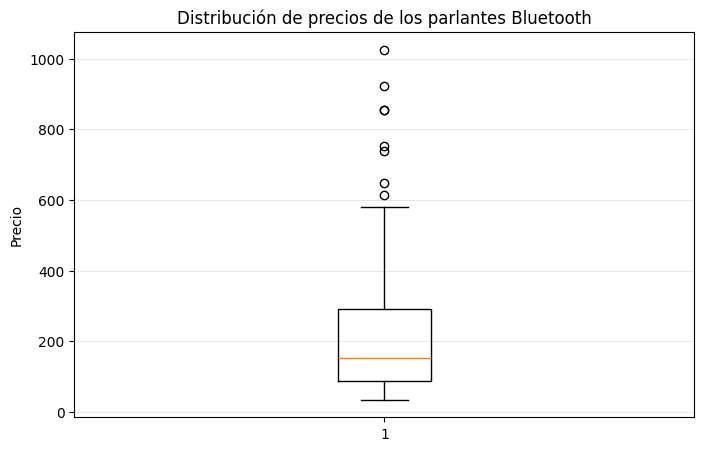

In [26]:
# ============================================================
# GRÁFICO DE CAJA DEL PRECIO
# ============================================================

plt.figure(figsize=(8, 5))
plt.boxplot(df_precio["precio_num"], vert=True)

plt.title("Distribución de precios de los parlantes Bluetooth")
plt.ylabel("Precio")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretación del gráfico de caja

El gráfico de caja muestra cómo se distribuyen los precios de los parlantes Bluetooth.  
Este gráfico permite identificar si la mayoría de productos se encuentra dentro de un rango similar de precios o si existen productos con precios muy altos o muy bajos en comparación con el resto.

In [ ]:
# ============================================================
# GRÁFICO DE BARRAS DE PRECIOS
# ============================================================

# Tomamos los primeros 20 productos con precio válido para que el gráfico sea legible
muestra = df_precio.head(20).copy()

# Crear nombres cortos para los productos
muestra["producto_n"] = ["Producto " + str(i) for i in range(1, len(muestra) + 1)]

plt.figure(figsize=(12, 6))
plt.bar(muestra["producto_n"], muestra["precio_num"])

plt.title("Precio de los primeros 20 productos con precio disponible")
plt.xlabel("Producto")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretación del gráfico de barras de precios

El gráfico de barras permite comparar los precios de los primeros productos obtenidos.  
Gracias a esta visualización, se puede observar qué productos son más económicos y cuáles tienen un precio más elevado dentro de la muestra analizada.

## 2. Gráfico de barras de los comentarios dentro de cada producto

La cantidad de comentarios es una variable importante en la decisión de compra porque puede reflejar la experiencia previa de otros compradores.

Sin embargo, al revisar el archivo CSV generado por el scraper, se observa que no se incluyó una columna específica de comentarios. Por ello, el código queda preparado para analizar esta variable si en una próxima extracción se incorpora la columna `comentarios`.

Para no inventar datos, en caso la columna no exista, se crea una columna auxiliar con valor 0 y se deja documentada esta limitación.

AVISO: El CSV original no tiene columna 'comentarios'.
Se crea una columna auxiliar con 0 para que el gráfico no genere error.
Para mejorar el proyecto, se recomienda corregir el scraper y extraer comentarios.


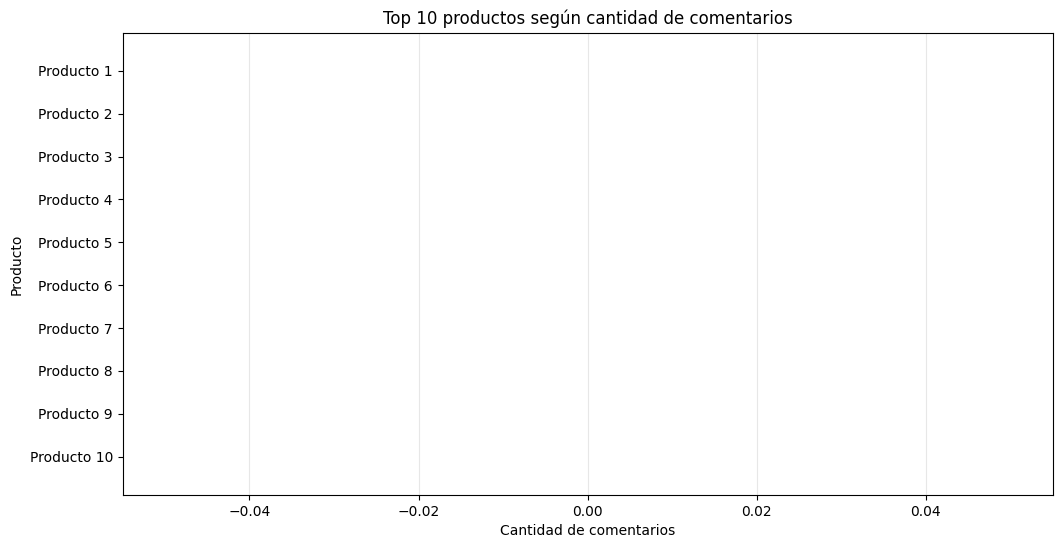

,id,comentarios_num,rating,link
0,B0GS99FG9P,0,4.4,https://www.amazon.com/-/es/dp/B0GS99FG9P/
1,B0CX1FRR27,0,4.6,https://www.amazon.com/-/es/dp/B0CX1FRR27/
2,B0GV3PNRNG,0,4.3,https://www.amazon.com/-/es/dp/B0GV3PNRNG/
3,B0F43NM23Q,0,4.6,https://www.amazon.com/-/es/dp/B0F43NM23Q/
4,B08X4YMTPM,0,4.8,https://www.amazon.com/-/es/dp/B08X4YMTPM/
5,B0D6WD2QSQ,0,4.7,https://www.amazon.com/-/es/dp/B0D6WD2QSQ/
6,B0GHSL9FPR,0,4.5,https://www.amazon.com/-/es/dp/B0GHSL9FPR/
7,B0FRRMD96F,0,4.5,https://www.amazon.com/-/es/dp/B0FRRMD96F/
8,B0BC27MM5Z,0,4.8,https://www.amazon.com/-/es/dp/B0BC27MM5Z/
9,B0G7GFDLQ2,0,4.8,https://www.amazon.com/-/es/dp/B0G7GFDLQ2/


In [27]:
# ============================================================
# GRÁFICO DE COMENTARIOS POR PRODUCTO
# ============================================================

if "comentarios" in df_100.columns:
    # Si existe la columna comentarios, se limpia con regex
    df_100["comentarios_num"] = df_100["comentarios"].apply(extraer_numero)
else:
    # Si no existe, se documenta la limitación
    print("AVISO: El CSV original no tiene columna 'comentarios'.")
    print("Se crea una columna auxiliar con 0 para que el gráfico no genere error.")
    print("Para mejorar el proyecto, se recomienda corregir el scraper y extraer comentarios.")

    df_100["comentarios_num"] = 0


# Seleccionar los 10 productos con mayor número de comentarios
top_comentarios = df_100.sort_values("comentarios_num", ascending=False).head(10).copy()

# Crear nombres cortos para el gráfico
top_comentarios["producto_n"] = ["Producto " + str(i) for i in range(1, len(top_comentarios) + 1)]

plt.figure(figsize=(12, 6))
plt.barh(top_comentarios["producto_n"], top_comentarios["comentarios_num"])

plt.title("Top 10 productos según cantidad de comentarios")
plt.xlabel("Cantidad de comentarios")
plt.ylabel("Producto")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

top_comentarios[["id", "comentarios_num", "rating", "link"]]

### Interpretación del gráfico de comentarios

El gráfico de comentarios permite identificar qué productos tienen mayor cantidad de opiniones de usuarios.

En este caso, el archivo CSV original no contiene la variable de comentarios, por lo que el análisis queda limitado. No obstante, el código está preparado para realizar correctamente el gráfico si se agrega esta columna al scraper.

Esta observación es importante porque demuestra que no se están inventando datos y que se reconoce una limitación real del proceso de extracción.

## 3. Comparación de precio de promoción y precio normal

La comparación entre precio normal y precio promocional permite analizar si un producto tiene descuento y cuánto podría ahorrar el comprador.

En el archivo CSV original solo existe una columna llamada `precio`. Por ese motivo, si no existen las columnas `precio_normal` y `precio_promocion`, el código usa el mismo precio como referencia. Esto evita inventar descuentos.

El código queda preparado para comparar correctamente ambas variables si el scraper logra extraerlas en una siguiente versión.

In [ ]:
# ============================================================
# COMPARACIÓN DE PRECIO NORMAL Y PRECIO PROMOCIONAL
# ============================================================

# Si existe precio_promocion, se usa esa columna.
# Si no existe, se usa el precio extraído originalmente.
if "precio_promocion" in df_100.columns:
    df_100["precio_promocion_num"] = df_100["precio_promocion"].apply(extraer_numero)
else:
    df_100["precio_promocion_num"] = df_100["precio_num"]


# Si existe precio_normal, se usa esa columna.
# Si no existe, se usa el mismo precio para no inventar descuentos.
if "precio_normal" in df_100.columns:
    df_100["precio_normal_num"] = df_100["precio_normal"].apply(extraer_numero)
else:
    print("AVISO: El CSV no tiene columna 'precio_normal'.")
    print("Se usará el mismo precio como precio normal para evitar inventar descuentos.")

    df_100["precio_normal_num"] = df_100["precio_num"]


# Seleccionar productos válidos para la comparación
comparacion = df_100.dropna(subset=["precio_promocion_num", "precio_normal_num"]).head(15).copy()

# Crear nombres cortos para el gráfico
comparacion["producto_n"] = ["Producto " + str(i) for i in range(1, len(comparacion) + 1)]

# Posiciones para las barras
x = np.arange(len(comparacion))
ancho = 0.40

plt.figure(figsize=(13, 6))

plt.bar(
    x - ancho/2,
    comparacion["precio_normal_num"],
    width=ancho,
    label="Precio normal"
)

plt.bar(
    x + ancho/2,
    comparacion["precio_promocion_num"],
    width=ancho,
    label="Precio promoción"
)

plt.title("Comparación entre precio normal y precio de promoción")
plt.xlabel("Producto")
plt.ylabel("Precio")
plt.xticks(x, comparacion["producto_n"], rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

comparacion[["id", "precio_normal_num", "precio_promocion_num", "link"]]

### Interpretación de la comparación de precios

El gráfico compara el precio normal y el precio promocional de los productos seleccionados.

En esta versión del archivo, ambos precios aparecen iguales porque el CSV original solo contiene una columna de precio. Esto significa que no se pudo calcular un descuento real a partir de los datos disponibles.

Sin embargo, la estructura del código permite realizar la comparación correctamente si en una versión posterior se agregan las columnas de precio normal y precio promocional.

## 4. Resumen estadístico

Se presenta un resumen estadístico de las principales variables numéricas disponibles: precio y rating.  
Esto permite observar valores como el promedio, mínimo, máximo y la dispersión de los datos.

In [ ]:
# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================

df_precio[["precio_num", "rating"]].describe()

## 5. Conclusiones

A partir del análisis de los 100 primeros productos relacionados con parlantes Bluetooth en Amazon, se observa que los precios presentan variación entre productos. El gráfico de caja permite identificar la distribución general de los precios, mostrando si la mayoría de productos se concentra en un rango similar o si existen valores atípicos.

El gráfico de barras de precios permite comparar de forma visual los primeros productos con precio disponible. Esta comparación ayuda al comprador a identificar rápidamente qué productos son más económicos y cuáles tienen un precio más elevado dentro de la categoría analizada.

Respecto al gráfico de comentarios, se identificó que el archivo CSV original no incluye una columna específica de comentarios. Por ello, se dejó documentada esta limitación en el código. Para una versión más completa del proyecto, se recomienda modificar el scraper para extraer la cantidad de comentarios de cada producto, ya que esta variable es importante en la decisión de compra porque refleja la experiencia previa de otros compradores.

En la comparación entre precio normal y precio promocional, el archivo original solo contiene una columna de precio. Por este motivo, no se inventaron descuentos y se utilizó el mismo precio como referencia. El código queda preparado para comparar correctamente ambas variables si en una próxima extracción se agregan las columnas de precio normal y precio promocional.

Finalmente, se concluye que la decisión de compra en Amazon no depende únicamente del precio. También influyen otros factores como el rating, la cantidad de comentarios, la disponibilidad del producto y el enlace directo de compra. Por ello, el análisis de datos permite organizar mejor la información y apoyar una decisión de compra más informada.